<a href="https://colab.research.google.com/github/Vlasovasona/ML-home-works/blob/main/hw_4_Vlasova_Sofia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = 'https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw04-knn-linreg/penguins_data.csv'
data = pd.read_csv(url)
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [ ]:
data = data.dropna()
print(data.isna().sum())

Species                0
Island                 0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [ ]:
data['Species'].unique()

array(['Chinstrap', 'Gentoo', 'Adelie'], dtype=object)

In [ ]:
data.shape

(325, 11)

In [ ]:
data = data.drop(index=data[data['Sex'] == '.'].index)

**Пояснение:** в датасете присутствует запись, у которой вместо пола ('Sex') указано постороннее значение. Было принято решение удалить эту запись, так как в датасете она всего одна. Поэтому удаление не нарушит нам полноту данных и мы можем пожертвовать одной строкой наблюдений.

In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [ ]:
data.head()

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971


In [ ]:
species_order = ['Chinstrap', 'Gentoo', 'Adelie']
enc = OrdinalEncoder(categories=[species_order])

data['Species'] = enc.fit_transform(data['Species'].values.reshape(-1, 1))

y = data['Species']

In [ ]:
X = data.drop(columns='Species')
X.shape

(324, 10)

In [ ]:
object_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop='first')
print("До:", X.shape[0])
encoded_data = encoder.fit_transform(X[object_columns])

encoded_df = pd.DataFrame(encoded_data,
                         columns=encoder.get_feature_names_out(object_columns))

encoded_df.isna().any().any()

До: 324


np.False_

In [ ]:
X = pd.concat([X.drop(columns=object_columns).reset_index(drop=True),
               encoded_df.reset_index(drop=True)],
              axis=1)
print("После:", X.shape[0])

После: 324


In [ ]:
X.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_MALE
0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,1.0,0.0,1.0,1.0
1,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,1.0,0.0,1.0,0.0
2,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,0.0,0.0,1.0,0.0
3,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,1.0,0.0,1.0,0.0
4,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,0.0,0.0,1.0,0.0


In [ ]:
y.head()

,Species
0,0.0
1,0.0
2,1.0
3,0.0
4,1.0


**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
print(X.shape)
print(y.shape)

(324, 11)
(324,)


In [ ]:
np.random.seed(51)
X_train, X_test, Y_train, Y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=51,
                                                    stratify=y)



---

**Почему выбран OneHotEncoder из sklearn а не pd.get_dummies**: если объснить на примере, то, например, есть у нас в train столбец "Цветочки", где встречаются только "Василек" и "Ромашка", мы обучим модель на этих данных и у нас будут только эти две категории. При этом в test попадет вредная запись где бдет для "Цветочки" указан "Пион", который может нам все испортить. Тогда test получит дополнительный столбец, который нарушит наш код если бы мы использовали pd.get_dummies. Но в sklearn можно указать что делать с неожиданными значениями столбцов, например игнорировать или сообщать об ошибке когда вы понимаете, что постороннее значение быть не может.


**Почему должен использоваться stratify**

Этот параметр отвечает за то, чтобы при разбиении на train и test уичывался баланс классов таргет переменной. В train должны попасть все виды пингвина для того, чтобы модель была обучена на более разнообразных данных. Если таргет переменная - категориальный признак, то целесообразно использовать этот параметр.

---



**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [ ]:
# масштабирование
from sklearn import preprocessing

normalizer = preprocessing.StandardScaler()
X_real_norm_np = normalizer.fit_transform(X_train)
X_train = pd.DataFrame(data=X_real_norm_np, columns=X_test.columns)
X_train.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_MALE
0,1.307241,-1.462203,0.400316,-0.779987,-0.932924,1.372089,0.745182,1.312590,-0.376051,0.368345,-0.948240
1,0.106606,0.455098,-1.044438,1.153039,0.638404,-0.485450,-1.657763,-0.761853,-0.376051,0.368345,-0.948240
2,0.046407,0.934423,1.197422,0.706956,-0.304393,1.398526,1.267469,1.312590,-0.376051,0.368345,1.054585
3,1.320618,-0.816957,-0.197513,-1.672153,-1.184337,1.693562,0.699884,1.312590,-0.376051,0.368345,-0.948240
4,-1.144194,-0.780086,0.898507,-1.226070,-0.807218,0.189998,-0.182856,-0.761853,-0.376051,0.368345,1.054585


In [ ]:
normalizer = preprocessing.StandardScaler()
X_real_norm_np = normalizer.fit_transform(X_test)
X_test = pd.DataFrame(data=X_real_norm_np, columns=X_train.columns)
X_test.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_MALE
0,1.374038,1.016956,-0.483416,1.823861,1.721442,-1.066806,0.451598,-0.762001,-0.425115,0.27735,0.902671
1,-1.202370,-0.508845,0.699608,-0.126991,-0.316882,0.341101,-0.389234,1.312335,-0.425115,0.27735,0.902671
2,-1.195223,-1.029412,0.000549,-0.261532,-0.616636,0.109508,-0.911735,-0.762001,-0.425115,0.27735,-1.107823
3,1.413345,-1.370473,1.129799,-0.665157,-0.976340,0.096893,0.537960,-0.762001,2.352304,0.27735,-1.107823
4,0.116208,-0.149833,-1.612666,1.151154,0.522428,-0.123457,-1.159190,-0.762001,-0.425115,0.27735,-1.107823


**Зачем нужно масштабирование данных в knn?**

kNN считает расстояния до соседних объектов текущего элемента и на основе этого выдает прогнозируемую метку класса текущего объекта, если данные не будут отмасштабированы, то они будут влиять на расстояние не пропорционально друг другу, одни признаки будут "доминировать" над другими, и точность kNN будет сильно снижена.



---



In [ ]:
# обучение
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

neighbors_amount_values = [1, 3, 5, 10, 15, 25]

models = []

for value in neighbors_amount_values:
  # на самом деле Евклидово расстояние используется по умолчанию
  model = KNeighborsClassifier(n_neighbors=value, metric='euclidean')
  model.fit(X_train[['Flipper Length (mm)', 'Body Mass (g)']], Y_train)

  models.append(model)

  Y_pred_test = model.predict(X_test[['Flipper Length (mm)', 'Body Mass (g)']])
  accuracy_test = np.mean(Y_test == Y_pred_test)

  Y_pred_train = model.predict(X_train[['Flipper Length (mm)', 'Body Mass (g)']])
  accuracy_train = np.mean(Y_train == Y_pred_train)
  print(f"{value} neighbors has an train accuracy of {accuracy_train:.2f} test accuracy of {accuracy_test:.2f}")

1 neighbors has an train accuracy of 0.97 test accuracy of 0.67
3 neighbors has an train accuracy of 0.89 test accuracy of 0.70
5 neighbors has an train accuracy of 0.85 test accuracy of 0.73
10 neighbors has an train accuracy of 0.84 test accuracy of 0.77
15 neighbors has an train accuracy of 0.85 test accuracy of 0.74
25 neighbors has an train accuracy of 0.84 test accuracy of 0.74


Наблюдения по полученным значениям: в зависимости от сида и random_state получаются разные accuracy на разных гиперпараметрах k. Путем тыка установлено, что, например, k = 25 нестабильно, но часто получает самое большое accuracy на test, но частенько и проигрывает меньшим значениям k. Стабильнее всего себя ведут **k = 10** и k = 15.



---



**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [ ]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [ ]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/pytho

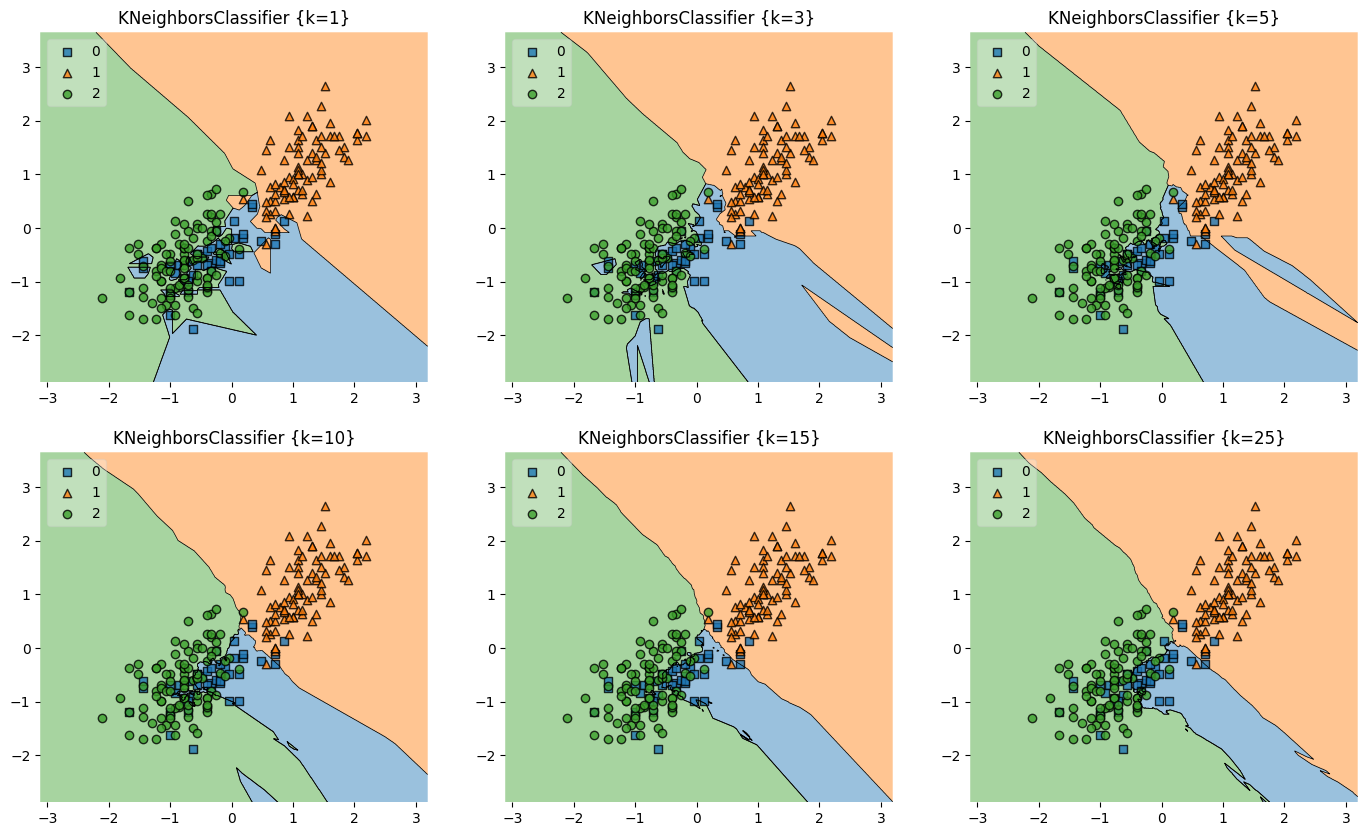

In [ ]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
from sklearn.neighbors import KNeighborsClassifier

gs = gridspec.GridSpec(2, 3)  # сетка 2x3

fig = plt.figure(figsize=(17, 10))

labels = [f'KNeighborsClassifier {{k={k}}}' for k in neighbors_amount_values]

for i in range(len(labels)):
    row = i // 3
    col = i % 3

    ax = plt.subplot(gs[row, col])
    plot_decision_regions(X=X_train[['Flipper Length (mm)', 'Body Mass (g)']].values,
                         y=Y_train.astype(np.int_).values,
                         clf=models[i],
                         legend=2)
    plt.title(labels[i])

plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

**Наиболее оптимально использовать 10-15 соседей.** Лучше всего это видно по задаче 1.3, в ней доля правильных ответов на test выше в сравнении с другими значениями гиперпараметра. При таком значении модель начинает учитывать несколько ближайших соседей. Такой подход позволяет модели лучше работать с новыми данными, хотя и немного снижает точность на обучающей выборке. Если обратиться к графику, то можно увидеть что, при значении k= 5 поверхность более **сглажена**.

При значении **k=1 (и k=3)** модель идеально будет предсказывать классы объектов на тренировочной выборке, но как только мы начем испытывать модель на новых данных (train) она покажет свою несосотоятельность, так как не будет иметь способности обращаться на новые данные. Поэтому выбор **k = 1 (3)** ведет к явному переобучению модели. Решающая поверхность это подтверждает **рваными** участками решающих поверхностей.

При k равном и 25 произойдет недообучение. Модель будет сильно обобщенной. При слишком большой ширине модель станосится слишком простой, поэтому k нужно подбирать индивидуально для каждой задачи.


В данном случае нам больше всего подошло значение **k = 10 или 15**.

---



### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

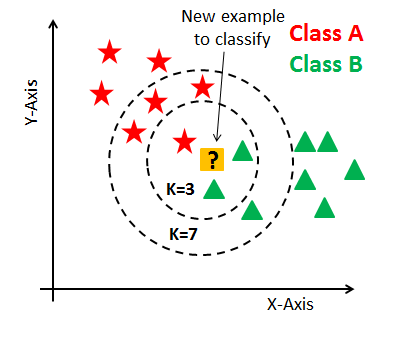

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [ ]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        '''Конструктор класса kNN
        :param k: кол-во соседей'''
        self.k = k

    def fit(self, X, y):
      '''Сохранение обучающих данных в соответствующие атрибуты
      :param X: Массив признаков обучающих данных
      :param Y: Массив целевых значений обучающих данных'''

      self.X_train = X
      self.Y_train = y

    def predict(self, X):
      ''' Метод для предсказания классов для новых данных.
      :param X: Массив признаков новых данных, для которых нужно предсказать классы
      :return: Массив предсказанных классов '''

      predictions = []
      X = np.array(X)

      for x in X:
          # евклидово расстояние от объекта до остальных в выборке
          distances = np.linalg.norm(self.X_train - x, axis=1)
          # сортировка по возрастанию расстояний до объекта, берем первые k значений
          indices = np.argsort(distances)[:self.k]
          # Получаем метки для найденных соседей
          labels = self.Y_train[indices]
          # Находим наиболее часто встречающуюся метку
          prediction = Counter(labels).most_common(1)[0][0]
          predictions.append(prediction)

      return np.array(predictions)

    def count_distance(self, x, y):
      return np.linalg.norm(x - y)

In [ ]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [ ]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [ ]:
neighbors_amount_values = [1, 3, 5, 10, 15, 25]
max_acc = [0, 0]
models = []

for value in neighbors_amount_values:
    model = KNN(k=value)
    model.fit(X_train.reset_index(drop=True), Y_train.reset_index(drop=True))

    models.append(model)

    Y_pred_test = model.predict(X_test)
    accuracy_test = np.mean(Y_test == Y_pred_test)
    if accuracy_test > max_acc[0]:
        max_acc[0], max_acc[1] = accuracy_test, value

print(f"Лучшее k: {max_acc[1]} с точностью {round(max_acc[0], 4)} на test")

Лучшее k: 5 с точностью 1.0 на test


train_test_split не сохраняет оригинальные индексы, поэтому использую reset_index для сброса индексов от 0 до длины датасета

### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [ ]:
data = pd.read_csv('https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw04-knn-linreg/diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [ ]:
data = data.dropna()
print(data.isna().sum())

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


In [ ]:
data = data.drop(columns='depth')

In [ ]:
data = data.drop(columns='Unnamed: 0')

In [ ]:
data.head()

,carat,cut,color,clarity,table,price,x,y,z
0,0.23,Ideal,E,SI2,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,58.0,335,4.34,4.35,2.75


Удалила столбец depth потому что он является призводным от x, y и z. Технически его можно исключить так как эту информацию можно получить из других столбцов.

Еще удалила столбец, дублирующий индексы


---



**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

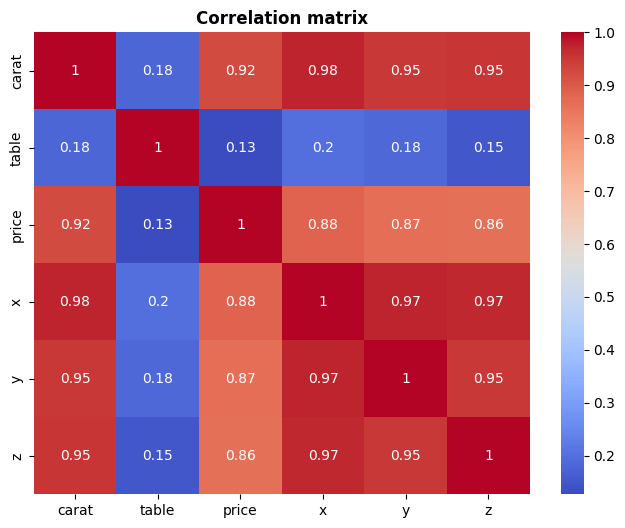

In [ ]:
target = 'price'
df = data.drop(['cut', 'clarity', 'color'], axis=1)
features = df.columns[~df.columns.isin([target])]

corr_matrix = df.corr()

# оставляем только вещественные признаки и целевую переменную
real_features = features[data[features].apply(lambda x:
                                              np.issubdtype(x.dtype,
                                                            np.number)).values]

corr_subset = corr_matrix.loc[real_features, target]

plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title('Correlation matrix', fontweight='bold')
plt.show()

Наибольшую прямую зависимость с целевой переменной имеет значение carat (0.92), что естесственно, т.к. чем больше карат у бриллианта тем выше его цена. Также яркая корреляци прослеживается между ценой и размерами бриллианта.

Обратная корреляция наблюдается между table и price, это можно объяснить тем, что слишком большой или слишком маленький table может негативно влиять на качество огранки и, соответсвенно, на цену

---



**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [ ]:
species_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
enc = OrdinalEncoder(categories=[species_order])
data['cut'] = enc.fit_transform(data['cut'].values.reshape(-1, 1))

species_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
enc = OrdinalEncoder(categories=[species_order])
data['color'] = enc.fit_transform(data['color'].values.reshape(-1, 1))

species_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
enc = OrdinalEncoder(categories=[species_order])
data['clarity'] = enc.fit_transform(data['clarity'].values.reshape(-1, 1))

In [ ]:
data.head()

,carat,cut,color,clarity,table,price,x,y,z
0,0.23,4.0,5.0,1.0,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,58.0,335,4.34,4.35,2.75


Принято решение кодировать при помощи OrdinalEncoder, так как нам даны упорядоченные значения для каждого признака, поэтому использование выбранного способа кодирования придаст некоторую линейную зависимость категориальным признакам, а для нас это было бы очень кстати.



---



**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3. Не забудьте про параметр `stratify`.

In [ ]:
y = data['price']
x = data.drop('price', axis=1)
np.random.seed(42)
X_train, X_test, Y_train, Y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=42
                                                    )


In [ ]:
X_train.head()

,carat,cut,color,clarity,table,x,y,z
19497,1.21,4.0,2.0,5.0,57.0,6.92,6.87,4.23
31229,0.31,4.0,5.0,3.0,56.0,4.38,4.36,2.71
22311,1.21,4.0,5.0,4.0,57.0,6.75,6.83,4.24
278,0.81,4.0,4.0,1.0,55.0,5.92,5.96,3.72
6646,0.79,4.0,1.0,5.0,56.0,5.94,5.95,3.67


**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [ ]:
normalizer = preprocessing.StandardScaler()
X_real_norm_np = normalizer.fit_transform(X_train)
X_train = pd.DataFrame(data=X_real_norm_np, columns=X_test.columns)
X_train.head()

,carat,cut,color,clarity,table,x,y,z
0,0.862659,0.982948,-0.825977,1.184867,-0.207099,1.055581,0.986556,0.968253
1,-1.029889,0.982948,0.938373,-0.030994,-0.656213,-1.207734,-1.202544,-1.168276
2,0.862659,0.982948,0.938373,0.576936,-0.207099,0.904099,0.951670,0.982309
3,0.021527,0.982948,0.350256,-1.246854,-1.105327,0.164512,0.192898,0.251391
4,-0.020530,0.982948,-1.414093,1.184867,-0.656213,0.182333,0.184176,0.181110


In [ ]:
normalizer = preprocessing.StandardScaler()
X_real_norm_np = normalizer.fit_transform(X_test)
X_test = pd.DataFrame(data=X_real_norm_np, columns=X_train.columns)
X_test.head()

,carat,cut,color,clarity,table,x,y,z
0,-1.177152,0.978051,-0.240174,1.784795,-0.642780,-1.562934,-1.523982,-1.536090
1,-0.454302,-0.808070,0.347087,1.179553,-0.198865,-0.251053,-0.269090,-0.394598
2,-0.836987,0.978051,0.934347,1.179553,-1.086695,-0.857909,-0.870024,-0.842525
3,-0.773206,0.084990,0.934347,1.179553,-0.198865,-0.715120,-0.737465,-0.799177
4,1.607947,0.978051,0.934347,-1.241416,-1.086695,1.533821,1.454177,1.556054


После масштабирования мы все еще можем проследить кореляцию между признаками, но w больше не отражают конкретные значения изменения признаков.

Например, при увеличении карата мы раньше могли проследить на сколько конкретно увеличиваются размеры бриллианта, теперь мы сможем лишь сказать, что коэффициент w говорит нам о том, как размеры бриллианта меняются при изменении карат на одно стандартное отклонение.



---



**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression().fit(X_train, Y_train)
print(f"Train: {mean_squared_error(Y_train, lr.predict(X_train))}")
print(f"Test: {mean_squared_error(Y_test, lr.predict(X_test))}")

Train: 1503740.2608821336
Test: 1456145.457550938


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [ ]:
coeff = lr.coef_ # коэффициенты
intercept = lr.intercept_ # свобдный член

print("Коэффициенты:")
index = 0
for column in X_train.columns:
  print(f"{column}: {round(coeff[index], 4)}")
  index += 1

print(f"Intercept: {round(intercept, 4)}")

Коэффициенты:
carat: 5002.741
cut: 171.3612
color: 555.0566
clarity: 837.7189
table: -17.0886
x: -756.6663
y: 62.3309
z: -158.0942
Intercept: 3951.4953


Самые большие по модулю коэффициенты у параметров carat, clarity, x и color. Коэффициенты в принципе не пропорциональны, встречаются от 17 по модулю до 5000.

Проблема таких больших коэффициентов в том, что при малейших колебаниях в признаках модель будет очень чувствительной, что приведет к переобучению.

---



**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [ ]:
from sklearn.linear_model import Lasso, Ridge

In [ ]:
# Lasso

lasso = Lasso(10.0).fit(X_train, Y_train)
print("Lasso")
print(f"Train: {mean_squared_error(Y_train, lasso.predict(X_train))}")
print(f"Test: {mean_squared_error(Y_test, lasso.predict(X_test))}")

Lasso
Train: 1512766.2516521085
Test: 1467316.0934007305


In [ ]:
coeff = lasso.coef_ # коэффициенты

print("Коэффициенты:")
index = 0
for column in X_train.columns:
  print(f"{column}: {round(coeff[index], 4)}")
  index += 1

Коэффициенты:
carat: 4581.6402
cut: 158.5108
color: 533.9831
clarity: 834.5202
table: -17.0219
x: -329.3481
y: -0.0
z: -111.257


In [ ]:
# Ringe

ridge = Ridge(10.0).fit(X_train, Y_train)
print("\nRidge")
print(f"Train: {mean_squared_error(Y_train, ridge.predict(X_train))}")
print(f"Test: {mean_squared_error(Y_test, ridge.predict(X_test))}")


Ridge
Train: 1503787.9407738938
Test: 1456277.4317303824


In [ ]:
coeff = ridge.coef_ # коэффициенты

print("Коэффициенты:")
index = 0
for column in X_train.columns:
  print(f"{column}: {round(coeff[index], 4)}")
  index += 1

Коэффициенты:
carat: 4971.4637
cut: 170.6616
color: 554.0151
clarity: 837.7937
table: -17.7188
x: -724.0065
y: 59.4619
z: -157.4797


Значения коэффициентов слегка изменились, но не сильно. Если значения коэффициентов практически не уменьшились, то можно предположить, что данные не сильно подвержены мультиколлинеарности, хотя и изначальная регрессия имеет давольно большие коэффициенты либо мы взяли слишком маленький гиперпараметр регуляризации.


---



**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

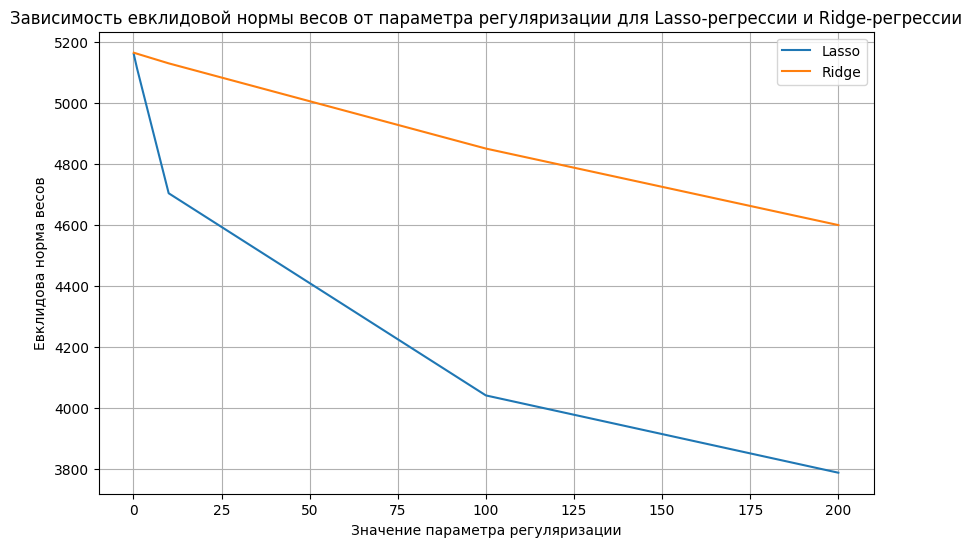

In [ ]:
alphas = [0.1, 1, 10, 100, 200]

ridge_norms = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, Y_train)
    coeff = ridge.coef_
    euclid_norm = np.linalg.norm(coeff)
    ridge_norms.append(euclid_norm)

lasso_norms = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, Y_train)
    coeff = lasso.coef_
    euclid_norm = np.linalg.norm(coeff)
    lasso_norms.append(euclid_norm)

plt.figure(figsize=(10, 6))
plt.plot(alphas, lasso_norms, label="Lasso")
plt.plot(alphas, ridge_norms, label="Ridge")
plt.xlabel('Значение параметра регуляризации')
plt.ylabel('Евклидова норма весов')
plt.title('Зависимость евклидовой нормы весов от параметра регуляризации для Lasso-регрессии и Ridge-регрессии')
plt.grid(True)
plt.legend()
plt.show()

Сильнее величину вектора снижает **Lasso**. Ее отличительной особенностью является то, что у признаков, которые не оказывают болього влияния на ответ, вес в результате оптимизации оказывается равным 0. Именно это свойство Lasso позволяет удобно отсеять признаки, слабо влияющие на таргет. (если обратимся к решению задания 3.8 и взглянем на коэффициентыЮ получившиеся после L1-регуляризации, то обнаружим что, например, у признака "y" коэффициент стал равень 0, значит этот признак не так важен для оценки стоимости бриллианта и его можно исключить).

---



**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [ ]:
from sklearn.linear_model import LassoCV

In [ ]:
lasso_cv = LassoCV(cv=5, alphas=alphas, max_iter=100000) # доя большего числа итераций добавила параметр max_iter
lasso_cv.fit(X_train, Y_train)

matrix = lasso_cv.mse_path_
used_alphas = lasso_cv.alphas_

mean_mses = matrix.mean(axis=1)

index_best = mean_mses.argmin()
print(f'Лучшее значение альфа {used_alphas[index_best]}')

Лучшее значение альфа 10.0


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [ ]:
lasso = Lasso(10.0).fit(X_train, Y_train)
coeff = lasso.coef_ # коэффициенты

print("Коэффициенты:")
index = 0
for column in X_train.columns:
  print(f"{column}: {round(coeff[index], 4)}")
  index += 1

Коэффициенты:
carat: 4581.6402
cut: 158.5108
color: 533.9831
clarity: 834.5202
table: -17.0219
x: -329.3481
y: -0.0
z: -111.257


Как я уже писала выше, самый большой коэффициент (наиболее информативные признаки) у carat, так как стоимость бриллианта напрямую и очень сильно зависит от этого признака, что объяснить можно даже здравым смыслом. В меньшей степени наблюдается прямая зависимость между цветом, чистотой и ценой бриллианта.

Параметр y при **a = 10** занулился, так как не имеет большого влияния на таргет. В целлом параметры x y и z сильно связаны потому что логично предположить, что бриллиант будет дорогим при отсутствии ассиметрии. При a = 1 обнуления в коэффициентах не произойдет, потому что коэффициент слишком мал.

Замечу, что при разных сид и random_state наиболее удачными получаются разные значения коэффициента. Чаще всего предпочтительным становится a = 10.


---



**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [ ]:
print("Lasso")
print(f"Train: {mean_squared_error(Y_train, lasso.predict(X_train))}")
print(f"Test: {mean_squared_error(Y_test, lasso.predict(X_test))}")

Lasso
Train: 1512766.2516521085
Test: 1467316.0934007305


In [ ]:
print("Standar linear regression")
print(f"Train: {mean_squared_error(Y_train, lr.predict(X_train))}")
print(f"Test: {mean_squared_error(Y_test, lr.predict(X_test))}")

Standar linear regression
Train: 1503740.2608821336
Test: 1456145.457550938


Для a = 10:

Ошибка в случае с Lasso немного выше чем у стандартной регрессии. Я могу связать это с тем, что при обнулении y модель потеряла способность улавливать пропорции бриллиантов (если вспомнить коэффициенты линейной регрессии, то там у параметра ширины был небольшой положительный коэффициент, который уравнивал отрицательные значения для глубины и высоты).

В принципе значения коэффициентов в глбальном отношении с использованием lasso не поменялось, поэтому вряд ли для этого датасета целесообразно использовать регурялизацию.

Для предсказаний **в данном датасете (!)** лучше использовать обычную линейную регрессию.

---

